# Import the Python Modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load data into data frames

In [2]:
df = pd.read_csv('StudentPerformanceFactors.csv')

In [ ]:
df.head()

After loading the data into a data frame, we can now explore the data frame before doing any analysis  

In [ ]:
df['Gender'].index

In [ ]:
parental_Exam_mean = df.groupby(['Parental_Education_Level', 'Family_Income'])[['Exam_Score']].mean().unstack()
parental_Exam_mean.reset_index()

parental_Exam_mean

In [ ]:
parental_Exam_mean.plot(kind='bar');

In [ ]:
df['Parental_Education_Level'].unique()

In [ ]:
df.columns

In [ ]:
df.info()

In [ ]:
# find out more
df['Teacher_Quality'].isnull().idxmax( )

In [ ]:
df['Teacher_Quality'].loc[125 : 129]

We can checkout the numerical data using `describe()`

In [ ]:
df.describe(include='all')

In [ ]:
df.columns

We can see that there are only two genders presented in the data frame.

In [ ]:
df.Gender.unique()

We can compare the performance of the first 100 students by gender using a line plot

I can use `.head(100)` or `.iloc[:100]` to get the first 100 students, using `.loc[0:100]` gets the first 100 students by index.

In [ ]:
male_100 = df[df.Gender == 'Male'].head(100)['Exam_Score']
female_100 = df[df.Gender == 'Female'].head(100)['Exam_Score']

In [ ]:
plt.figure(figsize=(12,6))

# Reset index for proper plotting
male_100 = male_100.reset_index(drop=True)
female_100 = female_100.reset_index(drop=True)

plt.plot(male_100.index, male_100.values, label='Male Students', marker='o', alpha=0.7)
plt.plot(female_100.index, female_100.values, label='Female Students', marker='s', alpha=0.7)

plt.xlabel('Student Number (100)')
plt.ylabel('Exam Score')
plt.title('Comparison of First 100 Male vs Female Students')
plt.legend()
plt.grid(True, alpha=0.3);

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))

# Plot 1: Line comparison
axes[0].plot(male_100.values, label='Male', alpha=0.7, linewidth=2)
axes[0].plot(female_100.values, label='Female', alpha=0.7, linewidth=2)
axes[0].set_xlabel('Student Index')
axes[0].set_ylabel('Exam Score')
axes[0].set_title('Exam Scores: First 100 Students by Gender')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Distribution comparison
axes[1].boxplot([male_100, female_100], labels=['Male', 'Female'])
axes[1].set_ylabel('Exam Score')
axes[1].set_title('Score Distribution Comparison')

plt.tight_layout()
plt.show()

# Print statistics
print("📊 Male Students (first 100):")
print(f"  Mean: {male_100.mean():.2f}")
print(f"  Median: {male_100.median():.2f}")
print(f"  Std: {male_100.std():.2f}")

print("\n📊 Female Students (first 100):")
print(f"  Mean: {female_100.mean():.2f}")
print(f"  Median: {female_100.median():.2f}")
print(f"  Std: {female_100.std():.2f}")

In [ ]:
df.School_Type

In [ ]:
plt.figure(figsize=(14,6))

sns.barplot(x='School_Type', y='Exam_Score', hue='Gender', data=df, errorbar='sd', capsize=0.1)
plt.title('Exam Scores by School Type and Gender (with Standard Deviation)')
plt.xticks(rotation=45);

We can come to a conclusion the the 1st 100 Students from both genders have almost the same scores, no big differece between the two.

In [ ]:
df.columns

Does Peer Influence affect student performance?

In [ ]:
peer_means = df.groupby('Peer_Influence')[['Previous_Scores', 'Exam_Score']].mean().reset_index()
peer_means

In [ ]:
peer_means.columns

In [ ]:
plt.figure(figsize=(10,6))

peer_means.plot(x='Peer_Influence', y=['Previous_Scores', 'Exam_Score'], kind='bar')
plt.title('Average Scores by Peer Influence')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.7);

We can conclude that peer influence had no effect on the Students low performance

**Box Plot Distribution**

In [ ]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.boxplot(x='Peer_Influence', y='Previous_Scores', data=df)
plt.title('Previous Score Distribution by Peer Influence')

plt.subplot(1,2,2)
sns.boxplot(x='Peer_Influence', y='Exam_Score', data=df)
plt.title('Exam Score Distribution by Peer Influence')

plt.tight_layout();

In [ ]:
df.columns

In [ ]:
tutoring_impact = df.groupby(['Tutoring_Sessions'])[['Previous_Scores', 'Exam_Score']].mean()
tutoring_impact

# Complete Failure Analysis  

**1: Identify failed Students first**

In [ ]:
# Define failure threshold
fail_threshold = 65 # Assuming 50% is the passing mark

# Create failed Students data frame
failed_students = df[df.Exam_Score < fail_threshold]

print(f"Number of failed students {len(failed_students)}")
print(f"Percentage failed: {(len(failed_students)/len(df)*100):.1f}%")


**2: Compare Failed vs Passed Students by Tutoring**

In [ ]:
# Add Pass/Fail category
df['Pass_Fail'] = df['Exam_Score'].apply(lambda x: 'Failed' if x < fail_threshold else 'Passed')

# Group by tutoring sessions and pass/fail
tutoring_breakdown = df.groupby(['Tutoring_Sessions', 'Pass_Fail']).size().unstack()
print("Student Distribution by Tutoring Sessions")
print(tutoring_breakdown)

In [ ]:
# Visualize
tutoring_breakdown.plot(kind='bar', stacked=True, figsize=(12,6), colormap='RdYlGn')
plt.title('Pass/Fail Distribution by Number of Tutoring Sessions')
plt.xlabel('Tutoring Sessions')
plt.ylabel('Number of Students')
plt.legend(title='Result')
plt.xticks(rotation=0);

In [ ]:
df.columns

In [ ]:
df['Hours_Studied'].agg(['mean', 'std', 'count'])

In [ ]:
df['Access_to_Resources'].unique()

In [ ]:
resource_means = df.groupby('Access_to_Resources')['Exam_Score'].mean()
resource_means

In [ ]:
resource_means.plot(kind='pie');

In [ ]:
df.columns

In [ ]:
df.info()

In [ ]:
grouped_data = df.groupby(['Internet_Access', 'Motivation_Level'])[['Exam_Score', 'Previous_Scores']].mean().reset_index()
grouped_data

**1. Grouped Bar Chart (Best for Comparison)**

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(x='Motivation_Level', y='Exam_Score', hue='Internet_Access', data=grouped_data)
plt.title('Average Exam Scores by Motivation Level and Internet Access')
plt.xlabel('Motivation Level')
plt.ylabel('Average Exam Score')
plt.legend(title='Internet Access')
plt.grid(True, alpha=0.3);

**2. Heatmap (See patterns at glance)**

In [ ]:
grouped_data

In [ ]:
# Pivot for heatmap
heatmap_data = grouped_data.pivot(index='Motivation_Level', columns='Internet_Access', values='Exam_Score')
heatmap_data

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', fmt='.1f', linewidths=0.5, cbar_kws={'label':'Avg Exam Score'})
plt.title('Average Exam Score: Motivatio Level vs Internet Access')
plt.tight_layout();

In [ ]:
df.hist(figsize=(20,30));

## Restart

In [ ]:
df.describe(include='all')

In [ ]:
df.hist();

In [ ]:
numeric_col = ['Hours_Studied', 'Attendence', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Session', 'Physical_Activity', 'Exam_Score']

In [ ]:
non_numeric_col = []
for col in df.columns:
    if col not in numeric_col:
        non_numeric_col.append(col)

non_numeric_col

In [ ]:
df.dropna()

In [ ]:
df.shape

In [ ]:
high_attendence = df[df['Attendance'] > 95].copy()
high_attendence

In [ ]:
df['Attendance'].agg(['max', 'min'])

In [ ]:
type(high_attendence)

In [ ]:
high_attendence.reset_index(drop=True, inplace=True)

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x='Parental_Involvement', y='Exam_Score', hue='Access_to_Resources', data=high_attendence)
plt.title('Parental Involvement vs Exam Score');

In [ ]:
high_attendence.head()

In [ ]:
sns.lineplot(x='Sleep_Hours', y='Previous_Scores', data=high_attendence)
plt.ylabel('Previous Scores')
plt.xlabel('Sleep Hours')
plt.title('Previous Scrore vs Sleep Hours');

In [ ]:
high_attendence['Extracurricular_Activities'].unique()

In [ ]:
sns.barplot(x='Extracurricular_Activities', y='Previous_Scores', hue='Gender', data=high_attendence);

In [ ]:
high_attendence['Gender'].unique()

In [ ]:
top_male_performers = high_attendence[high_attendence['Gender'] == 'Male'].copy()
top_female_performers = high_attendence[high_attendence['Gender'] == 'Female'].copy()

In [ ]:
top_male_attendance

In [ ]:
top_female_performers

In [ ]:
high_attendence[high_attendence['Gender'] == 'Female']

In [ ]:
high_attendence.shape

In [ ]:
df['Hours_Studied'].describe()

In [ ]:
df.notnull().sum()

In [ ]:
print(f"Count of Hours Studied: {df['Hours_Studied'].count()}")

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df, x='Hours_Studied')
plt.ylabel('Count')
plt.xlabel('Hours Studied')
plt.title("Histgram of Hours Studied")
plt.show()

In [ ]:
fig = px.histogram(df, x='Hours_Studied', title='Histogram of Hours Studied')

fig.show()

In [ ]:
df.columns

In [ ]:
df['Family_Income'].unique()

## Exploration of Distance from Home 


### Line plot

In [ ]:
plot_data = df.groupby('Distance_from_Home')[['Exam_Score', 'Previous_Scores']].sum()


plt.figure(figsize=(10,6))
plt.plot(plot_data.index, plot_data['Exam_Score'], marker='o', label='Exam Score')
plt.plot(plot_data.index, plot_data['Previous_Scores'], marker='s', label='Previous Score')
plt.xlabel('Distance from Home')
plt.ylabel('Total Score')
plt.title('Total Scores by Distance from Home')
plt.legend()
plt.show()

### Bar plot

In [ ]:
plot_data.plot(kind='bar')
plt.xlabel('Distance from Home')
plt.ylabel('Total Score')
plt.xticks(rotation=45)
plt.title('Total Scores by Distance from Home')
plt.legend(title='Score Type')
plt.tight_layout()
plt.show()

### Stacked bar plot

In [ ]:
plt.figure(figsize=(10,6))
plot_data.plot(kind='bar', stacked=True)
plt.xlabel('Distance from Home')
plt.ylabel('Total Score')
plt.title('Total Scores by Distance from Home (Stacked)')
plt.xticks(rotation=45)
plt.legend(title='Score Type')
plt.tight_layout()
plt.show();

From all the visualizations here, we can conclude that **Distance from Home** does have an effect on the students overall performance in the previous and most recent exams.

## Exploring the School Type

In [ ]:
# Count how many students in each school type
print('Count of Students in each school type \n', df['School_Type'].value_counts())

In [ ]:
# Percentage of Students in each school type
print(df['School_Type'].value_counts(normalize=True) * 100)

I see that pubic school had a total of 4598 students (69%) and private school had 2009 (30%).

### Basic Distribution of Students

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.countplot(df, x='School_Type')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Number of Students by School Type')
plt.show()

### Exam Comparison

In [ ]:
df.groupby('School_Type')['Exam_Score'].agg(['mean', 'median', 'std'])

In [ ]:
# Box plot
plt.figure(figsize=(8,6))
sns.boxplot(x='School_Type', y='Exam_Score', data=df)
plt.title('Exam Scores: Private vs Publics')
plt.show()

In [ ]:
# Compare across multiple columns
metrics = ['Exam_Score', 'Previous_Scores', 'Hours_Studied', 'Attendance']
school_comparison = df.groupby('School_Type')[metrics].mean()

school_comparison

In [ ]:
#Visualize
school_comparison.plot(kind='bar', figsize=(10,6))
plt.title('School Type Comparison: Key Metrics')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### School Type vs Other Categories

In [ ]:
# School type by gender
cross_gender = pd.crosstab(df['School_Type'], df['Gender'])
print(cross_gender)

In [ ]:
# School type by parental involvement
cross_parent = pd.crosstab(df['School_Type'], df['Parental_Involvement'])
print(cross_parent)

# Visualize
cross_parent.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Parental Involvement by School Type')
plt.xlabel('School Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Parental Involvement')
plt.show()

### Correlation with Other Factors

In [ ]:
# See if school type interacts with other factors
comparison = df.groupby('School_Type').agg({
    'Exam_Score': 'mean',
    'Hours_Studied': 'mean',
    'Attendance': 'mean',
    'Sleep_Hours': 'mean'
}).round(2)

print(comparison)

# Heatmap of differences
plt.figure(figsize=(8,5))
sns.heatmap(comparison.T, annot=True, cmap='coolwarm', center=0)
plt.title('Average Metrics by School Type')
plt.show()

### Interaction with Distance/Income

In [ ]:
# School type by family income
income_school = pd.crosstab(df['School_Type'], df['Family_Income'])
print(income_school)

# School type by distance from home
distance_school = df.groupby('School_Type')['Distance_from_Home'].sum()
print(distance_school)

### Impact on Academic Performance

In [ ]:
# Exam score distribution by school type
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(data=df, x='Exam_Score', hue='School_Type', bins=20, alpha=0.5)
plt.title('Exam Score Distribution')

plt.subplot(1,2,2)
sns.kdeplot(data=df, x='Exam_Score', hue='School_Type', fill=True, alpha=0.3)
plt.title('Density Plot')

plt.tight_layout()
plt.show()

### Exploring Tutoring Sessions

Getting the Exam and Previous scores to plot and see the trend

In [6]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

**Ploting Averages**

In [8]:
# Group by tutoring_sessions and calculate mean scores
tutoring_avg = df.groupby('Tutoring_Sessions')[['Exam_Score', 'Previous_Scores']].mean().reset_index()

tutoring_avg

,Tutoring_Sessions,Exam_Score,Previous_Scores
0,0,66.489755,75.668209
1,1,66.980266,74.816888
2,2,67.567010,75.290479
3,3,67.894737,74.240431
4,4,68.229236,74.235880
5,5,69.067961,75.582524
6,6,71.666667,82.611111
7,7,69.857143,80.714286
8,8,69.000000,78.000000


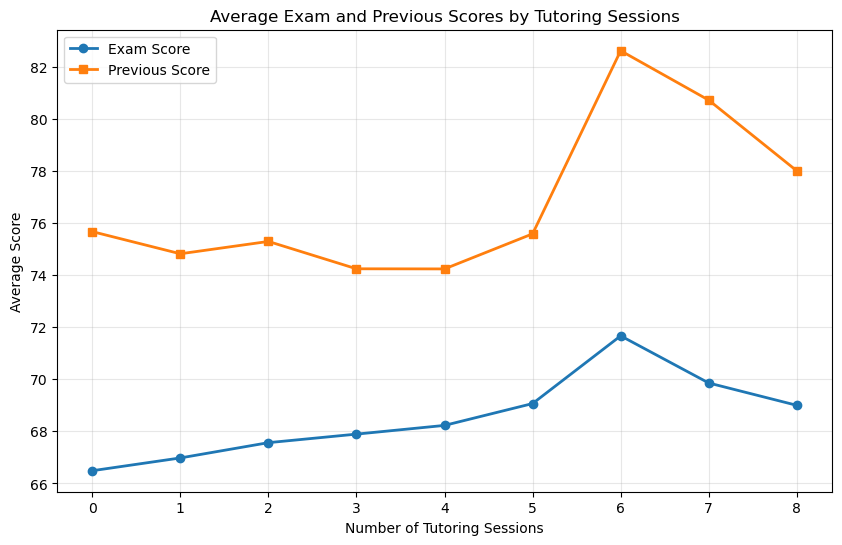

In [11]:
# Plot line graph
plt.figure(figsize=(10,6))
plt.plot(tutoring_avg['Tutoring_Sessions'], tutoring_avg['Exam_Score'], marker='o', label='Exam Score', linewidth=2)
plt.plot(tutoring_avg['Tutoring_Sessions'], tutoring_avg['Previous_Scores'], marker='s', label='Previous Score', linewidth=2)

plt.xlabel('Number of Tutoring Sessions')
plt.ylabel('Average Score')
plt.title('Average Exam and Previous Scores by Tutoring Sessions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Plotting Median**

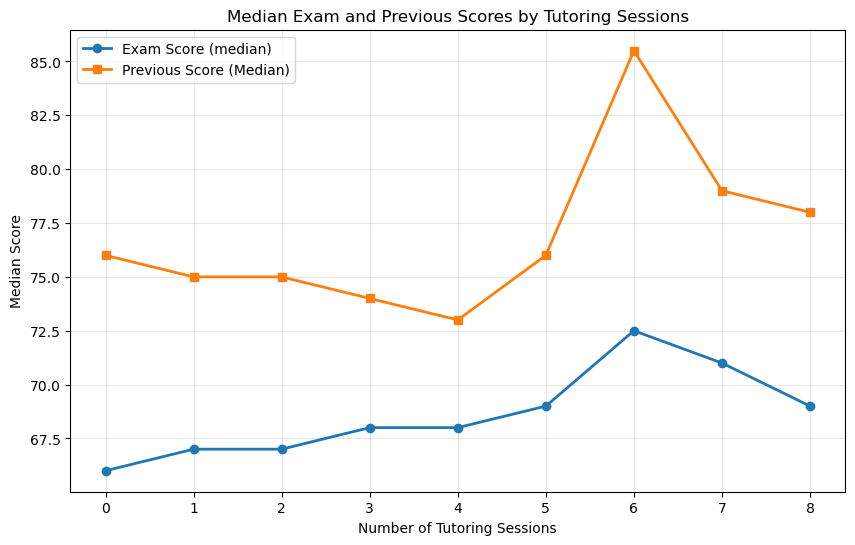

In [12]:
# Group by tutoring_sessions and calculate mean scores
tutoring_median = df.groupby('Tutoring_Sessions')[['Exam_Score', 'Previous_Scores']].median().reset_index()

plt.figure(figsize=(10,6))
plt.plot(tutoring_median['Tutoring_Sessions'], tutoring_median['Exam_Score'], marker='o', label='Exam Score (median)', linewidth=2)
plt.plot(tutoring_median['Tutoring_Sessions'], tutoring_median['Previous_Scores'], marker='s', label='Previous Score (Median)', linewidth=2)

plt.xlabel('Number of Tutoring Sessions')
plt.ylabel('Median Score')
plt.title('Median Exam and Previous Scores by Tutoring Sessions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Add Confidence Interval (Shows Variation)**

In [14]:
tutoring_stats = df.groupby('Tutoring_Sessions')[['Exam_Score', 'Previous_Scores']].agg(['mean', 'std', 'count']).reset_index()
tutoring_stats

Tutoring_Sessions Exam_Score                 Previous_Scores             \
                          mean       std count            mean        std   
0                 0  66.489755  3.881009  1513       75.668209  14.518585   
1                 1  66.980266  3.854574  2179       74.816888  14.279319   
2                 2  67.567010  3.851053  1649       75.290479  14.406963   
3                 3  67.894737  3.646791   836       74.240431  14.198957   
4                 4  68.229236  3.651111   301       74.235880  15.108083   
5                 5  69.067961  4.779987   103       75.582524  14.541708   
6                 6  71.666667  4.200840    18       82.611111  13.390685   
7                 7  69.857143  4.099942     7       80.714286  10.387722   
8                 8  69.000000       NaN     1       78.000000        NaN   

         
  count  
0  1513  
1  2179  
2  1649  
3   836  
4   301  
5   103  
6    18  
7     7  
8     1

In [15]:
# Calculate mean and standard deviation
tutoring_stats = df.groupby('Tutoring_Sessions')[['Exam_Score', 'Previous_Scores']].agg(['mean', 'std', 'count']).reset_index()

plt.figure(figsize=(10,6))
plt.plot(
    tutoring_stats['Tutoring_Sessions'], 
    tutoring_stats['mean'] - tutoring_stats['std'],
    tutoring_stats['mean'] + tutoring_stats['std'],
    alpha=0.2, label='Std Dev')

plt.xlabel('Number of Tutoring Sessions')
plt.ylabel('Exam Score')
plt.title('Exam Score by Tutoring Sessions (with Variation)')
plt.legend()
plt.grid(True, apha=0.3)
plt.show()

KeyError: 'mean'

<Figure size 1000x600 with 0 Axes>

**Box Plot (Shows Full Distribution)**

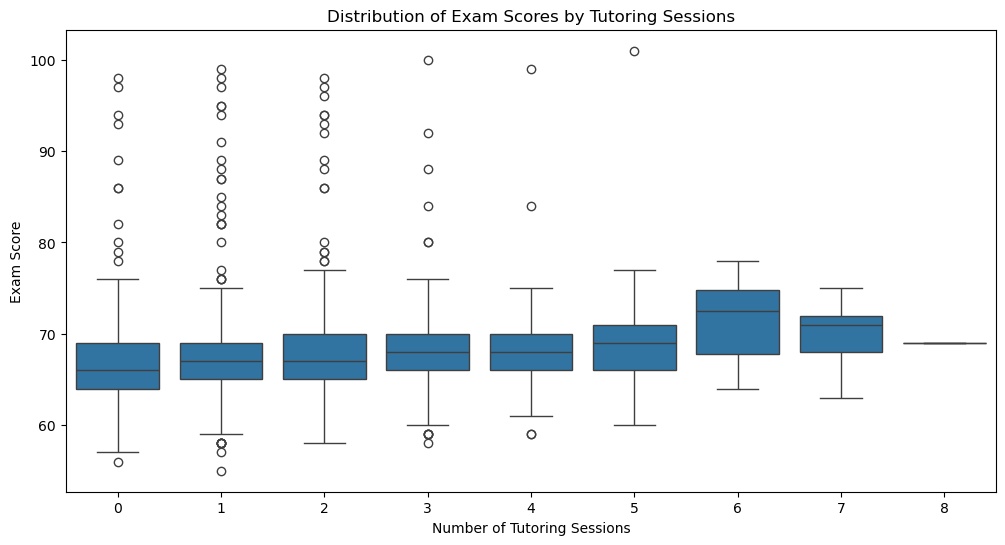

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Tutoring_Sessions', y='Exam_Score', data=df)
plt.xlabel('Number of Tutoring Sessions')
plt.ylabel('Exam Score')
plt.title('Distribution of Exam Scores by Tutoring Sessions')
plt.show()

This distribution has so many outliers between the first 4 tutoring sessions.

**Scatter Plot with Transparency (For Moderate Data)**

In [17]:
df.shape

(6607, 20)

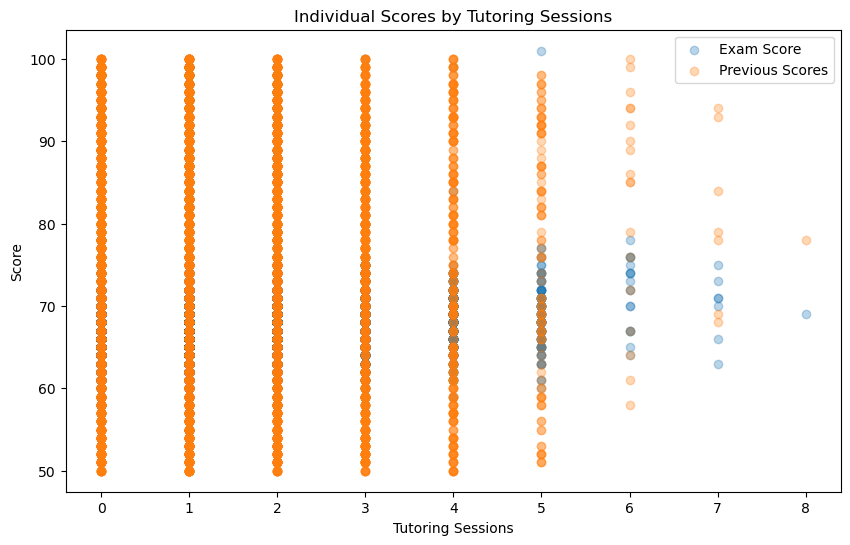

In [18]:
plt.figure(figsize=(10,6))
plt.scatter(df['Tutoring_Sessions'], df['Exam_Score'], alpha=0.3, label='Exam Score')
plt.scatter(df['Tutoring_Sessions'], df['Previous_Scores'], alpha=0.3, label='Previous Scores')
plt.xlabel('Tutoring Sessions')
plt.ylabel('Score')
plt.title('Individual Scores by Tutoring Sessions')
plt.legend()
plt.show()

This visulization isn't so good.